#  Grape Leaf Disease Classification using CNN and VGG16

This project aims to classify grape leaf diseases into 4 categories:
 'Black_rot', 'Esca_(Black_Measles)', 'Healthy', and 'Leaf_blight_(Isariopsis_Leaf_Spot)'.
 In this notebook, we train two models:
 1. A custom Convolutional Neural Network (CNN) built from scratch
 2. A Transfer Learning model using pre-trained VGG16
 The goal is to compare their performance on the same dataset.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
data_dir = "/kaggle/input/augmented-grape-disease-detection-dataset/Final Training Data"

In [3]:
import os 

classes=os.listdir(data_dir)
print("Classes: ", classes)

class_counts= {}
for class_name in classes:
    class_path= os.path.join(data_dir, class_name)
    count= len(os.listdir(class_path))
    class_counts[class_name]= count

print("Number of images per class:")
for c, count in class_counts.items():
    print(f"{c:35}: {count}")

Classes:  ['ESCA', 'Healthy', 'Leaf Blight', 'Black Rot']
Number of images per class:
ESCA                               : 3000
Healthy                            : 3000
Leaf Blight                        : 3000
Black Rot                          : 3000


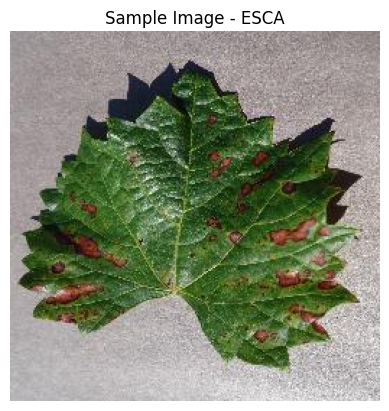

In [4]:
import matplotlib.pyplot as plt
import cv2
import random

random_class = random.choice(classes)
sample_path= os.path.join(data_dir, random_class)
random_img= random.choice(os.listdir(sample_path))

img=cv2.imread(os.path.join(sample_path, random_img))
img_rgb= cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #cv2 - bgr and matplotlib - rgb

plt.imshow(img_rgb)
plt.title(f"Sample Image - {random_class}")
plt.axis("off")
plt.show()


In [5]:
#Image preprocessing and data loading
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = data_dir

img_size=224 #important size for VGG16
batch_size=32

datagen= ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator= datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator=datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=True,
    seed=42
)

2025-06-21 08:40:07.601618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750495207.856996      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750495207.929031      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 9600 images belonging to 4 classes.
Found 2400 images belonging to 4 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model= Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_size,img_size,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation="relu"),
    Conv2D(512, (3,3), activation="relu"),
    Flatten(),
    Dropout(0.5),
    Dense(250, activation="relu"),
    Dropout(0.5),
    Dense(4, activation="softmax")
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1750495225.166174      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750495225.166990      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
model.compile(optimizer="adam",loss="categorical_crossentropy", metrics=["accuracy"])

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop= EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history=model.fit(train_generator,validation_data=val_generator,epochs=20,callbacks=[early_stop])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1750495231.428188      79 service.cc:148] XLA service 0x7e5588005990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750495231.429470      79 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750495231.429495      79 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750495231.921962      79 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/300 ━━━━━━━━━━━━━━━━━━━━ 1:07:09 13s/step - accuracy: 0.3750 - loss: 1.3836

I0000 00:00:1750495240.746571      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


300/300 ━━━━━━━━━━━━━━━━━━━━ 106s 309ms/step - accuracy: 0.5989 - loss: 1.0098 - val_accuracy: 0.8596 - val_loss: 0.4148
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 122ms/step - accuracy: 0.9045 - loss: 0.2588 - val_accuracy: 0.9488 - val_loss: 0.1702
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.9552 - loss: 0.1309 - val_accuracy: 0.9625 - val_loss: 0.1323
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step - accuracy: 0.9652 - loss: 0.1147 - val_accuracy: 0.9887 - val_loss: 0.0411
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 122ms/step - accuracy: 0.9772 - loss: 0.0750 - val_accuracy: 0.9679 - val_loss: 0.0899
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - accuracy: 0.9754 - loss: 0.0753 - val_accuracy: 0.9783 - val_loss: 0.0629
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - accuracy: 0.9873 - loss: 0.0389 - val_accuracy: 0.9783 - val_loss: 0.0647


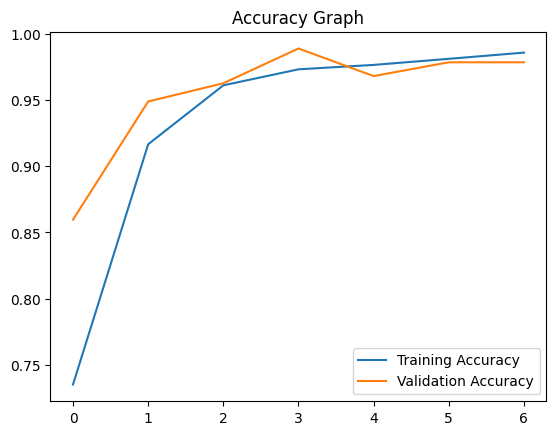

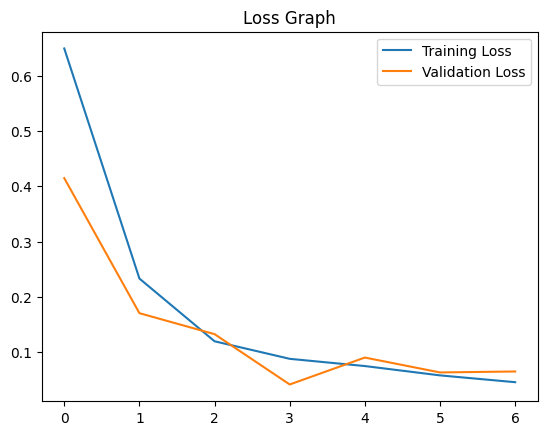

In [9]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss Graph")
plt.show()

In [10]:
model.save("grape_classifier_model.h5")

In [11]:
loss, acc=model.evaluate(val_generator)
print(f"Validation Accuracy: {acc:.2f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9907 - loss: 0.0354
Validation Accuracy: 0.99


# Transfer Learning

In [12]:
from tensorflow.keras.applications import VGG16

base_model=VGG16(weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3))

#freezing
for layer in base_model.layers:
    layer.trainable=False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
from tensorflow.keras.optimizers import Adam
model= Sequential([
    base_model,
    Flatten(),
    Dropout(0.5),
    Dense(250, activation="relu"),
    Dropout(0.5),
    Dense(4, activation="softmax")
])
model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

In [14]:
#we add early stopping
history=model.fit(train_generator, validation_data=val_generator,epochs=20, callbacks=[early_stop])

Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 85s 233ms/step - accuracy: 0.6703 - loss: 0.7950 - val_accuracy: 0.9337 - val_loss: 0.1688
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step - accuracy: 0.9096 - loss: 0.2254 - val_accuracy: 0.9429 - val_loss: 0.1376
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.9364 - loss: 0.1624 - val_accuracy: 0.9654 - val_loss: 0.0964
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step - accuracy: 0.9511 - loss: 0.1276 - val_accuracy: 0.9663 - val_loss: 0.0928
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step - accuracy: 0.9620 - loss: 0.0981 - val_accuracy: 0.9708 - val_loss: 0.0815
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.9677 - loss: 0.0881 - val_accuracy: 0.9575 - val_loss: 0.0981
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step - accuracy: 0.9682 - loss: 0.0843 - val_accuracy: 0.9717 - val_loss: 0.0731
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.9710 - loss: 0

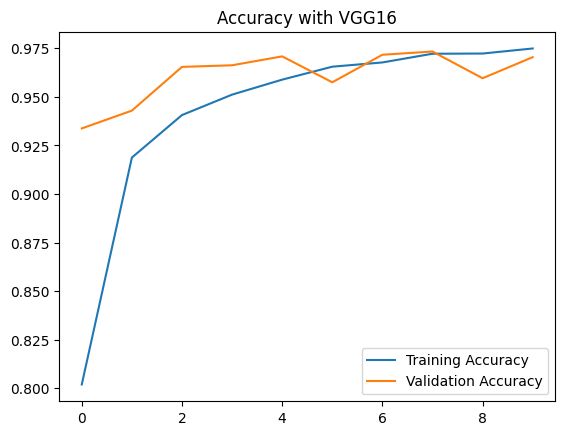

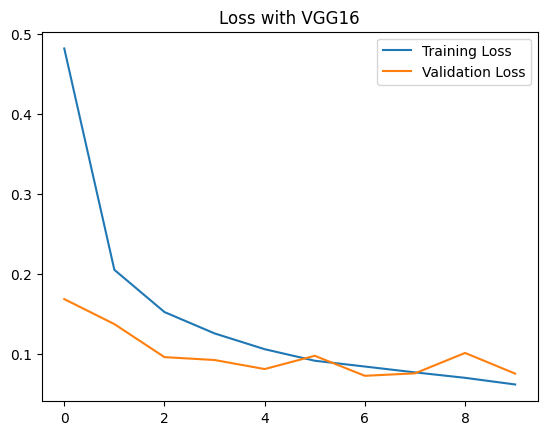

In [15]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy with VGG16")
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss with VGG16")
plt.show()

In [16]:
model.save("grape_classifier_vgg16.h5")

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [18]:
#Prediction with shuffle=False

val_generator = datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False  
)


Found 2400 images belonging to 4 classes.


In [19]:
# Real classes
true_labels = val_generator.classes

# Predictions
pred_probs = model.predict(val_generator)
pred_labels = np.argmax(pred_probs, axis=1)  # one-hot - class


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step


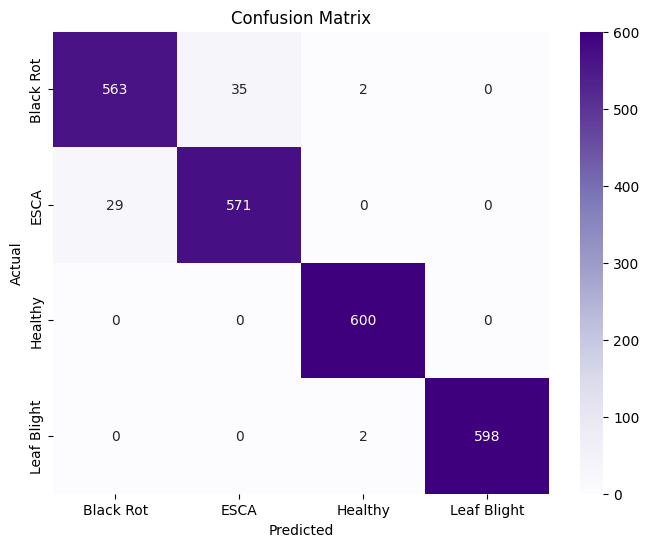

In [20]:
cm = confusion_matrix(true_labels, pred_labels)
class_names = list(val_generator.class_indices.keys()) 

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [21]:
report = classification_report(true_labels, pred_labels, target_names=class_names)
print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

   Black Rot       0.95      0.94      0.94       600
        ESCA       0.94      0.95      0.95       600
     Healthy       0.99      1.00      1.00       600
 Leaf Blight       1.00      1.00      1.00       600

    accuracy                           0.97      2400
   macro avg       0.97      0.97      0.97      2400
weighted avg       0.97      0.97      0.97      2400




# Results Summary:

 The custom CNN model achieved a validation accuracy of approximately 97%. It successfully learned to distinguish between 4 classes of grape leaf images. In the second phase, we implemented a Transfer Learning approach using a pre-trained VGG16 model. This model slightly outperformed the custom CNN, reaching a validation accuracy of approximately 98%. The comparison indicates that transfer learning can provide a performance boost by leveraging learned features from large-scale datasets such as ImageNet.
However, it is worth noting that the custom CNN—despite learning from scratch—delivered a high and sufficient level of performance, and did so with faster training and lower computational cost compared to the VGG16-based model.

Resources

- ChatGPT – For explanations, debugging support, and model architecture suggestions.

- Course Materials & Old Projects – Lecture notes, previous image classification notebooks, and lab examples were used for guidance and inspiration.